# Week 6 — Day 1: Sprint 1 Kickoff — Neural Network Foundations & Baseline Model

**Dataset:** Healthcare Stroke Prediction (capstone project)
**Task:** Sprint 1 planning close-out + baseline model (Logistic Regression, imbalance-aware)

---

## Objective

Enter Phase 3 of the program. Complete Sprint 1 planning, finalize the capstone dataset with a brief EDA, and train a **baseline model** that every later model must beat. Alongside the hands-on work, understand the building block of deep learning — the **neuron** — as a natural extension of the weighted-sum-plus-bias math used since Week 2.


## Lesson Content

### 1.1 — Why Deep Learning, and Why Now

Weeks 3–5 covered classical ML: linear/logistic regression, tree-based models, and unsupervised clustering — all of which work well on structured, tabular data with a manageable number of features. Deep learning earns its complexity on **unstructured or high-dimensional data**: images, text, audio, and other cases where hand-crafted features are hard to design. Phase 3's capstone stays tabular, so the baseline here is intentionally simple — but the neuron math below sets up Sprint 2+ if the project extends toward richer feature representations.

### 1.2 — The Neuron

A single neuron performs almost exactly the same computation as logistic regression:

$$z = (w_1 x_1 + w_2 x_2 + \dots + w_n x_n) + b = \mathbf{w} \cdot \mathbf{x} + b$$
$$\text{output} = \text{activation}(z)$$

This is the Week 2 dot product, plus a **bias** term `b`, passed through an **activation function**. With a sigmoid activation, a single neuron *is* logistic regression.

### 1.3 — Layers and Depth

- **Input layer** — one node per feature, no computation.
- **Hidden layer(s)** — neurons that transform the input into intermediate representations.
- **Output layer** — produces the final prediction (e.g., a probability for binary classification).

A network is called **deep** when it has more than one hidden layer — stacking transformations lets the model learn increasingly abstract representations of the data.

### 1.4 — Weights and Biases as Learned Parameters

Every connection between neurons carries a weight, and every neuron carries a bias. These are the parameters the network learns. Day 3 of this sprint arc covers how they're updated — via **backpropagation** and gradient descent, the same optimization idea used to fit the Week 3 logistic regression, just applied through many layers instead of one.


---

## Hands-On Lab: Sprint 1 Kickoff & Baseline

**Sprint goal:** *Understand the data and establish a baseline model to beat.*

Steps:
1. Load the stroke-risk dataset and finalize the data dictionary.
2. Run a brief EDA (class balance, key distributions).
3. Build a minimal, leak-free preprocessing + Logistic Regression pipeline (`class_weight="balanced"`).
4. Evaluate with imbalance-aware metrics: precision, recall, F1, ROC-AUC — not raw accuracy.
5. Record the baseline score in Markdown — this is the number Sprint 2+ models must beat.


### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay
)

sns.set_style("whitegrid")


### Step 1: Load the Dataset & Data Dictionary

| Column | Description |
|---|---|
| `id` | Patient identifier (drop — no signal) |
| `gender` | Male / Female / Other |
| `age` | Patient age |
| `hypertension` | 0 = No, 1 = Yes |
| `heart_disease` | 0 = No, 1 = Yes |
| `ever_married` | Yes / No |
| `work_type` | Private, Self-employed, Govt_job, children, Never_worked |
| `Residence_type` | Urban / Rural |
| `avg_glucose_level` | Average blood glucose level |
| `bmi` | Body mass index (contains missing values, encoded as `N/A`) |
| `smoking_status` | formerly smoked / never smoked / smokes / Unknown |
| `stroke` | **Target** — 1 = stroke, 0 = no stroke (~5% positive class) |


In [2]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv", na_values="N/A")
df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
df.info()
print("\nMissing values:\n", df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB

Missing values:
 id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work

In [ ]:
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

### Step 2: Quick EDA — Class Balance

Confirming the imbalance that motivates `class_weight="balanced"` in the baseline model, and recording it as the naive-baseline reference point.


stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


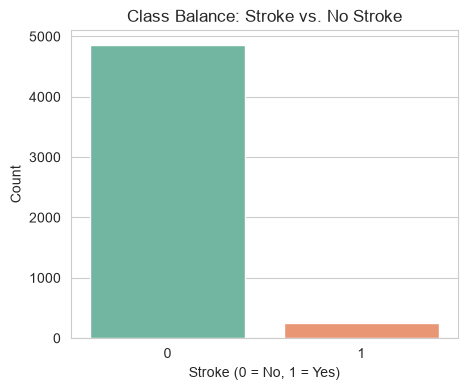


Naive baseline (predict majority class 'No Stroke' every time): 95.1% accuracy — but 0% recall on the class we care about.


In [5]:
stroke_counts = df["stroke"].value_counts(normalize=True) * 100
print(stroke_counts)

plt.figure(figsize=(5, 4))
sns.countplot(x="stroke", data=df, hue="stroke", palette="Set2", legend=False)
plt.title("Class Balance: Stroke vs. No Stroke")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

print(f"\nNaive baseline (predict majority class 'No Stroke' every time): "
      f"{stroke_counts[0]:.1f}% accuracy — but 0% recall on the class we care about.")


### Step 3: Minimal Preprocessing Pipeline

Drop the non-predictive `id` column, split numeric vs. categorical features, and chain imputation/scaling/encoding inside a single leak-free `Pipeline` (as established in Week 4 Day 5).


In [6]:
df = df.drop(columns=["id"])

X = df.drop(columns=["stroke"])
y = df["stroke"]

numeric_features = ["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease"]
categorical_features = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


### Step 4: Stratified Train/Test Split

`stratify=y` preserves the ~5% positive-class ratio in both splits — essential for an imbalanced target.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train stroke rate: %.2f%% | Test stroke rate: %.2f%%" %
      (y_train.mean() * 100, y_test.mean() * 100))


Train shape: (4088, 10) | Test shape: (1022, 10)
Train stroke rate: 4.87% | Test stroke rate: 4.89%


### Step 5: Baseline Model — Logistic Regression (`class_weight="balanced"`)

This is the Sprint 1 baseline. It's deliberately simple: no feature engineering, no tuning. Every model built in Sprint 2+ (including any neural network) must beat these numbers to justify its added complexity.


In [8]:
baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

baseline_pipeline.fit(X_train, y_train)
y_pred = baseline_pipeline.predict(X_test)
y_proba = baseline_pipeline.predict_proba(X_test)[:, 1]


### Step 6: Evaluate — Imbalance-Aware Metrics

In [9]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")
print("\n", classification_report(y_test, y_pred))


Precision: 0.138
Recall:    0.800
F1-score:  0.235
ROC-AUC:   0.844

               precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022



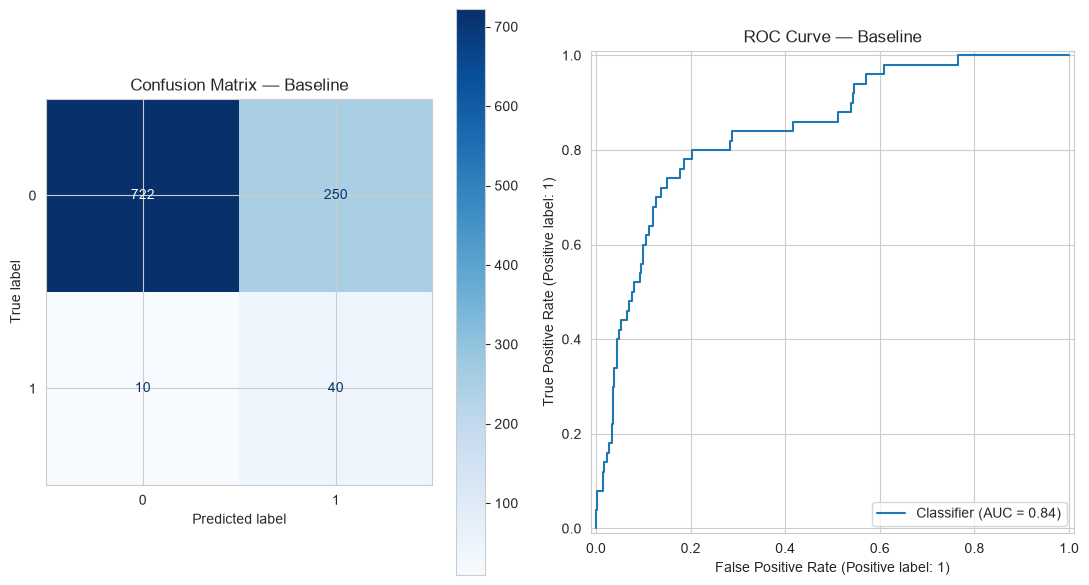

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 6))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], cmap="Blues")
axes[0].set_title("Confusion Matrix — Baseline")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title("ROC Curve — Baseline")

plt.tight_layout()
plt.show()


### Step 7: Record the Baseline (Sprint 1, Task 5 — Acceptance Criteria Met)

> **Baseline to beat (Logistic Regression, `class_weight="balanced"`):**
> - Precision: *0.138*
> - Recall: *0.8*
> - F1-score: *0.235*
> - ROC-AUC: *0.844*
>
> Any model trained in later sprints — including neural network approaches introduced later this week — must improve on **recall and ROC-AUC** without letting precision collapse, since missed stroke cases (false negatives) are the costlier error in this problem.

